In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

x_train = torch.FloatTensor([[1],[2],[3]])
y_train = torch.FloatTensor([[2],[4],[6]])

print(x_train, x_train.shape)
print(y_train, y_train.shape)

tensor([[1.],
        [2.],
        [3.]]) torch.Size([3, 1])
tensor([[2.],
        [4.],
        [6.]]) torch.Size([3, 1])


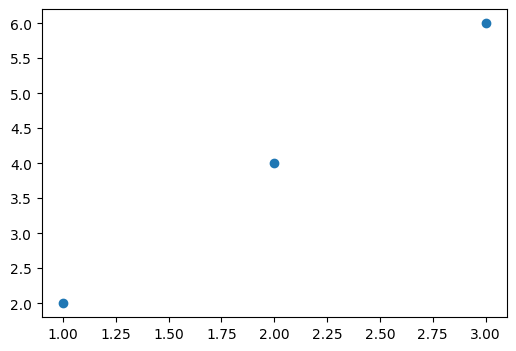

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train)

In [4]:
model = nn.Linear(1,1) #기울기, bias를 랜덤으로 설정
print(model)

y_pred = model(x_train)
print(y_pred)
print(list(model.parameters()))

# Linear(in_features=1, out_features=1, bias=True)
# tensor([[0.1479],
#         [1.0295],
#         [1.9110]], grad_fn=<AddmmBackward0>)
# [Parameter containing:
# tensor([[0.8815]], requires_grad=True), Parameter containing:
# tensor([-0.7336], requires_grad=True)]

Linear(in_features=1, out_features=1, bias=True)
tensor([[1.5945],
        [2.3591],
        [3.1236]], grad_fn=<AddmmBackward0>)
[Parameter containing:
tensor([[0.7645]], requires_grad=True), Parameter containing:
tensor([0.8300], requires_grad=True)]


In [5]:
print(0.8815*1 + -0.7336)
print(0.8815*2 + -0.7336)
print(0.8815*3 + -0.7336)

# 0.14789999999999992
# 1.0293999999999999
# 1.9108999999999998

0.14789999999999992
1.0293999999999999
1.9108999999999998


In [6]:
loss = nn.MSELoss()(y_pred, y_train)
loss

# tensor(9.6581, grad_fn=<MseLossBackward0>)

tensor(3.7102, grad_fn=<MseLossBackward0>)

In [7]:
list(model.parameters())
# [Parameter containing:
#  tensor([[0.8815]], requires_grad=True),
#  Parameter containing:
#  tensor([-0.7336], requires_grad=True)]
optimizer = optim.SGD(model.parameters(), lr = 0.01)

In [8]:
optimizer.zero_grad()
# 기울기 값을 일단 초기화
loss.backward()
#loss값의 기울기를 구해준다
optimizer.step()

In [9]:
list(model.parameters())

# [Parameter containing:
#  tensor([[0.8466]], requires_grad=True),
#  Parameter containing:
#  tensor([0.8628], requires_grad=True)]

[Parameter containing:
 tensor([[0.8466]], requires_grad=True),
 Parameter containing:
 tensor([0.8628], requires_grad=True)]

In [10]:
epochs = 1000

for epoch in range(epochs + 1):
    y_pred = model(x_train) # 현재 모델의 예측값
    loss = nn.MSELoss()(y_pred, y_train) #로스값
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss: .6f}')

# Epoch: 0/1000 Loss:  2.971597
# Epoch: 100/1000 Loss:  0.116835
# Epoch: 200/1000 Loss:  0.072197
# Epoch: 300/1000 Loss:  0.044613
# Epoch: 400/1000 Loss:  0.027568
# Epoch: 500/1000 Loss:  0.017035
# Epoch: 600/1000 Loss:  0.010527
# Epoch: 700/1000 Loss:  0.006505
# Epoch: 800/1000 Loss:  0.004020
# Epoch: 900/1000 Loss:  0.002484
# Epoch: 1000/1000 Loss:  0.001535


Epoch: 0/1000 Loss:  2.971597
Epoch: 100/1000 Loss:  0.116835
Epoch: 200/1000 Loss:  0.072197
Epoch: 300/1000 Loss:  0.044613
Epoch: 400/1000 Loss:  0.027568
Epoch: 500/1000 Loss:  0.017035
Epoch: 600/1000 Loss:  0.010527
Epoch: 700/1000 Loss:  0.006505
Epoch: 800/1000 Loss:  0.004020
Epoch: 900/1000 Loss:  0.002484
Epoch: 1000/1000 Loss:  0.001535


In [11]:
x_test = torch.FloatTensor([[5]])
y_pred = model(x_test)
y_pred

tensor([[9.8762]], grad_fn=<AddmmBackward0>)

In [12]:
y_pred

tensor([[9.8762]], grad_fn=<AddmmBackward0>)

In [13]:
device = torch.device('cuda' if torch.cuda.is_available()else 'cpu')
device

device(type='cpu')

In [14]:
X_train = torch.FloatTensor([[73, 80, 75],
                             [93, 88, 93],
                             [89, 91, 90],
                             [96, 98, 100],
                             [73, 66, 70],
                             [85, 90, 88],
                             [78, 85, 82]]).to(device)

y_train = torch.FloatTensor([[152], [185], [180], [196], [142], [175], [155]]).to(device)


In [15]:
model = nn.Linear(3,1).to(device)
# 독립변수 3개 종속변수 1개 랜덤 초기화
model


Linear(in_features=3, out_features=1, bias=True)

In [16]:
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [17]:
loss_fn = nn.MSELoss()

In [18]:
epochs = 1000

for epoch in range (epochs+1):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss: .6f}')

# Epoch: 0/1000 Loss:  21585.962891
# Epoch: 100/1000 Loss:  24.979015
# Epoch: 200/1000 Loss:  23.283005
# Epoch: 300/1000 Loss:  23.146479
# Epoch: 400/1000 Loss:  22.982256
# Epoch: 500/1000 Loss:  22.792973
# Epoch: 600/1000 Loss:  22.580563
# Epoch: 700/1000 Loss:  22.346350
# Epoch: 800/1000 Loss:  22.091402
# Epoch: 900/1000 Loss:  21.816732
# Epoch: 1000/1000 Loss:  21.523197

Epoch: 0/1000 Loss:  21585.962891
Epoch: 100/1000 Loss:  24.979015
Epoch: 200/1000 Loss:  23.283005
Epoch: 300/1000 Loss:  23.146479
Epoch: 400/1000 Loss:  22.982256
Epoch: 500/1000 Loss:  22.792973
Epoch: 600/1000 Loss:  22.580563
Epoch: 700/1000 Loss:  22.346350
Epoch: 800/1000 Loss:  22.091402
Epoch: 900/1000 Loss:  21.816732
Epoch: 1000/1000 Loss:  21.523197


In [19]:
x_test = torch.FloatTensor([[98,99,100]]).to(device)
y_pred = model(x_test)
y_pred

# tensor([[196.9363]], grad_fn=<AddmmBackward0>)

tensor([[196.9363]], grad_fn=<AddmmBackward0>)